# NASA Airfoil Noise Prediction

## Project overview

This project uses a linear regression model to estimate the **scaled sound pressure level (SSPL)** produced by an airfoil. It is based on the NASA Airfoil Self-Noise dataset and explores how operating conditions and airfoil geometry relate to measured aerodynamic noise.

The workflow follows a complete introductory machine-learning pipeline: download and inspect the data, explore distributions and correlations, separate predictor variables from the target, train and evaluate a linear regression model, save the trained model, and expose it through a simple Gradio interface.

## Dataset and variables

Each row is one airfoil test observation. The inputs are frequency (`f`, Hz), angle of attack (`alpha`, degrees), chord length (`c`, m), free-stream velocity (`U_infinity`, m/s), and suction-side displacement thickness (`delta`, m). The target is `SSPL`, the scaled sound pressure level in decibels.

## Important note

Linear regression is used here as an interpretable baseline. Aerodynamic noise can have non-linear relationships with the input variables, so the evaluation results should be used to judge whether a more advanced model is needed. Run the cells from top to bottom so the dataset path and trained model are available when later cells need them.

In [416]:
# STEP 1 — Download the NASA Airfoil Self-Noise dataset from Kaggle.
# The returned folder path is used in the next cell to load the CSV file.
# Install kagglehub first if it is not already available in your environment.
import kagglehub
fedesoriano_airfoil_selfnoise_dataset_path = kagglehub.dataset_download('fedesoriano/airfoil-selfnoise-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'airfoil-selfnoise-dataset' dataset.
Data source import complete.


In [417]:
# STEP 2 — Import libraries for data handling, visualization, and numerical work.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [418]:
# Load the CSV dataset into a pandas DataFrame.
# Displaying df lets us verify the column names and inspect sample observations.
df = pd.read_csv(f"{fedesoriano_airfoil_selfnoise_dataset_path}/AirfoilSelfNoise.csv")
df

,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
...,...,...,...,...,...,...
1498,2500,15.6,0.1016,39.6,0.052849,110.264
1499,3150,15.6,0.1016,39.6,0.052849,109.254
1500,4000,15.6,0.1016,39.6,0.052849,106.604
1501,5000,15.6,0.1016,39.6,0.052849,106.224


## Exploratory data analysis

Before fitting a model, the next cells examine the dataset. Histograms show the range and shape of every variable, line plots give a quick view of the recorded sequence, and the correlation heatmap highlights linear relationships. These checks help identify unusual values, scale differences, and variables that may be useful predictors of `SSPL`.

array([[<Axes: title={'center': 'f'}>, <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'c'}>,
        <Axes: title={'center': 'U_infinity'}>],
       [<Axes: title={'center': 'delta'}>,
        <Axes: title={'center': 'SSPL'}>]], dtype=object)

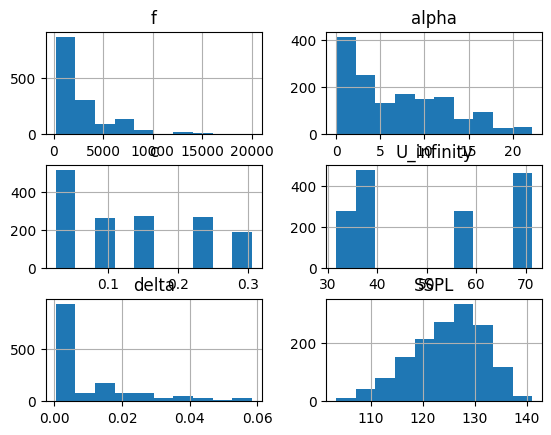

In [419]:
# Plot a histogram for each feature and the target to inspect their distributions.
df.hist()


<Axes: >

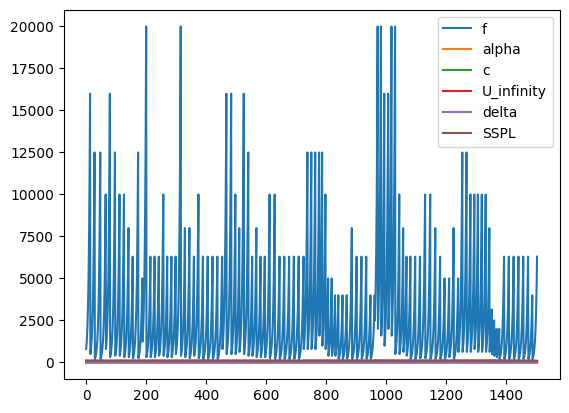

In [420]:
df.plot.line()

<Axes: >

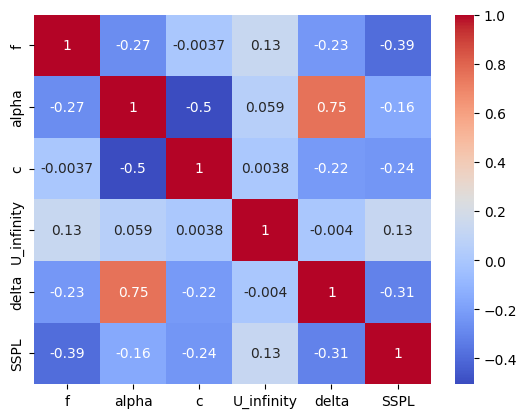

In [421]:
# Correlations summarize linear relationships; they do not prove causation.
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [422]:
# Select displacement thickness (delta) for a focused univariate check.
dgrees=df['delta']

<Axes: >

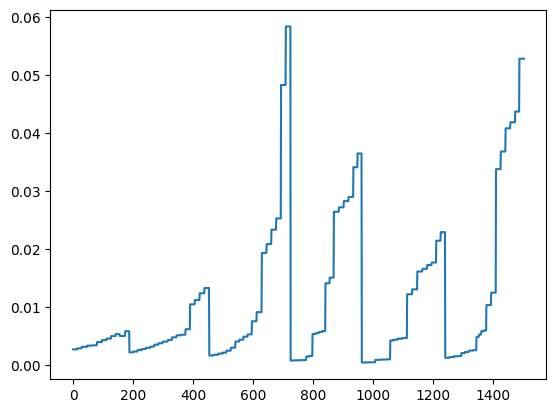

In [423]:
dgrees.mean()
dgrees.plot.line()

2886.3805721889553
200
20000
3152.573136930677


<Axes: >

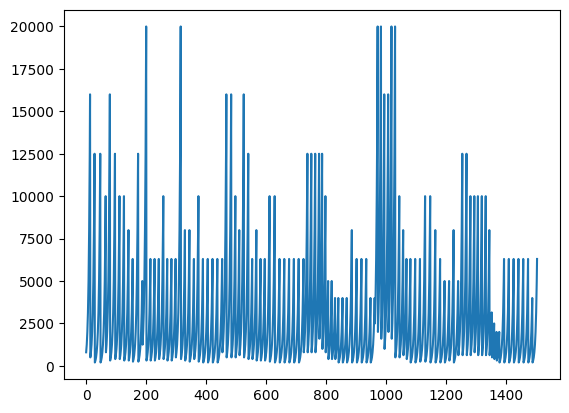

In [424]:
fregunsy=df['f']
print(fregunsy.mean())
print(fregunsy.min())
print(fregunsy.max())
print(fregunsy.std())
fregunsy.plot.line()


124.83594278110448
103.38
140.987
6.898656621628728


<Axes: >

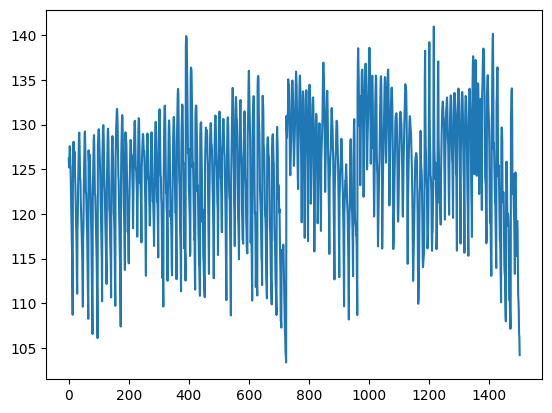

In [425]:
sspl=df["SSPL"]
print(sspl.mean())
print(sspl.min())
print(sspl.max())
print(sspl.std())
sspl.plot.line()

In [426]:
df.mean()

,0
f,2886.380572
alpha,6.782302
c,0.136548
U_infinity,50.860745
delta,0.011140
SSPL,124.835943


## Preparing the modelling data

Machine-learning models learn a target from input features. Here, `X` contains the five airfoil and flow variables, while `y` contains the SSPL values to predict. The data is then split into training and test sets: the model learns only from the training set, and the held-out test set provides an unbiased estimate of performance on unseen observations.

In [427]:
# X contains the predictor columns; y is the SSPL prediction target.
x=df.drop('SSPL',axis=1)
y=df['SSPL']

In [428]:
print(x.shape)
print(y.shape)

(1503, 5)
(1503,)


In [429]:
from sklearn.model_selection import train_test_split

In [430]:
# Reserve 30% of the observations for testing. random_state makes the split reproducible.
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=250)

In [431]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1052, 5)
(451, 5)
(1052,)
(451,)


## Training a linear regression baseline

Linear regression models SSPL as a weighted linear combination of the input variables. It is a useful baseline because its predictions and coefficients are easy to interpret. The fitted model is then used to create predictions for both the training data and the unseen test data.

In [432]:
# Import the baseline regression algorithm from scikit-learn.
from sklearn.linear_model import LinearRegression


In [433]:
# Create an unfitted linear regression model.
lr_model=LinearRegression()

In [434]:
# Fit the model using only the training features and target values.
train= lr_model.fit(x_train,y_train)

In [435]:
# Predict SSPL for the training set and the held-out test set.
lr_model.fit(x_train, y_train)
y_pred_lr_train = lr_model.predict(x_train)
y_pred_lr_test = lr_model.predict(x_test)

## Evaluating the model

The next cells report two standard regression metrics. **Mean Squared Error (MSE)** is the average squared prediction error, so lower values are better. **R-squared (R²)** is the proportion of variance in SSPL explained by the model, so values closer to 1 indicate a better fit. Comparing train and test results also helps reveal overfitting: a large gap would mean the model fits the training data much better than new data.

In [436]:
# Calculate MSE and R-squared separately for train and test predictions.
from sklearn.metrics import mean_squared_error, r2_score

mse_lr_train = mean_squared_error(y_train, y_pred_lr_train)
mse_lr_test = mean_squared_error(y_test, y_pred_lr_test)
r2_lr_train = r2_score(y_train, y_pred_lr_train)
r2_lr_test = r2_score(y_test, y_pred_lr_test)
print("MSE (Train):", mse_lr_train)
print("MSE (Test):", mse_lr_test)
print("R2 (Train):", r2_lr_train)
print("R2 (Test):", r2_lr_test)

MSE (Train): 23.379455890578082
MSE (Test): 22.379887155552204
R2 (Train): 0.5142022163931528
R2 (Test): 0.5147573596245394


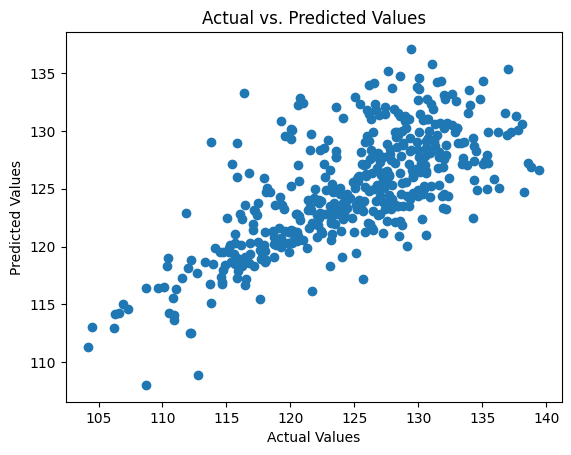

In [437]:
# Points close to the diagonal pattern indicate predictions close to actual SSPL values.
plt.scatter(y_test, y_pred_lr_test)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

## Saving the trained model

After training, the fitted estimator is serialized with `joblib`. Saving the model avoids retraining it every time a prediction app is started. Keep `AirNoise.pkl` in the same working directory as the deployment cell or update the file path when running the interface elsewhere.

In [438]:
import joblib

# Save the fitted model so it can be loaded later for prediction.
joblib.dump(lr_model, 'AirNoise.pkl')

print('Linear Regression model saved to AirNoise.pkl')

Linear Regression model saved to AirNoise.pkl


In [439]:
import streamlit as st

In [440]:
@st.cache_resource
def load_components():
    # هنا نقوم بتحميل الموديل المحفوظ مسبقاً (Linear Regression Model)
    model = joblib.load('AirNoise.pkl')
    return model

In [441]:
lr_model_loaded = load_components()

In [442]:
# Install pyngrok if you haven't already
!pip install pyngrok -q

# Set your ngrok authtoken (replace 'YOUR_NGROK_AUTH_TOKEN' with your actual token)
# You can get your authtoken from your ngrok dashboard: https://dashboard.ngrok.com/get-started/your-authtoken
from pyngrok import ngrok
ngrok.set_auth_token('YOUR_NGROK_AUTH_TOKEN')

# Run the Streamlit app
# The app.py file was created in a previous step.
!streamlit run app.py &>/dev/null&

In [443]:
pip install --upgrade gradio

In [444]:
import gradio as gr


## Interactive prediction interface

This final section builds a Gradio application for trying the saved model. The user enters values for the same five features used during training, and the app returns a predicted SSPL in decibels. Input column names must remain identical to the training data so that the model receives each value in the correct feature.

The slider limits should normally be kept within the ranges covered by the dataset. Predictions far outside those ranges are extrapolations and may be less reliable.

In [445]:
import gradio as gr
import joblib
import pandas as pd

# Load the saved model. The file must be available in the current working directory.
model = joblib.load('AirNoise.pkl')

def predict_sspl(f, alpha, c, U_infinity, delta):
    """Build one correctly named feature row and return the model's SSPL prediction."""
    input_data = pd.DataFrame([{
        'f': f,
        'alpha': alpha,
        'c': c,
        'U_infinity': U_infinity,
        'delta': delta
    }])
    prediction = model.predict(input_data)[0]
    return f"{prediction:.3f} dB"

# Create a user interface with one slider for each feature used during training.
iface = gr.Interface(
    fn=predict_sspl,
    inputs=[
        gr.Slider(minimum=200, maximum=20000, step=1, value=2000, label="Frequency (f) [Hz]"),
        gr.Slider(minimum=0.0, maximum=15.6, step=0.1, value=0.0, label="Angle of Attack (alpha) [degrees]"),
        gr.Slider(minimum=0.0254, maximum=0.3048, step=0.0001, value=0.3048, label="Chord Length (c) [m]"),
        gr.Slider(minimum=31.7, maximum=71.3, step=0.1, value=71.3, label="Free-stream Velocity (U_infinity) [m/s]"),
        gr.Slider(minimum=0.000401, maximum=0.052849, step=0.000001, value=0.002663, label="Suction Side Displacement Thickness (delta) [m]")
    ],
    outputs=gr.Textbox(label="Predicted Sound Pressure Level (SSPL)"),
    title="NASA Airfoil Noise Prediction (Linear Regression Model)",
    description="Enter the airfoil parameters to predict the Sound Pressure Level (SSPL)."
)

# Launch the local or hosted Gradio interface, depending on the notebook environment.
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fe4fa2c9c9ea9fe9d6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [446]:
import torch
import gc

with torch.no_grad():
    torch.cuda.empty_cache()

gc.collect()

15974